# SuSteelAible — NLP Pipeline
**Contributors:** [@am0ebe](https://github.com/am0ebe) · [@MJR-data](https://github.com/MJR-data) | **Focus:** Decarbonization barriers & motivators in EU steel sustainability reports (2013–2025)

## Pipeline

```
data/reports/ (PDFs)
    ↓ [1] ClimateBERT             → cache/*.json
    ↓ [2] BERT Visualization      → out/bert/
    ↓ [3] RAG Extraction          → out/rag/
    ↓ [4] Topic Modeling          → out/topics/
```

**Pre-computed results** are committed to `results/` — see `results/RESULTS.md` for a summary or browse `results/topics/` for interactive HTML visualizations. Run this notebook to reproduce or extend.

**Caching:** Each step caches output — first run is slower (model download, encoding); subsequent runs load from cache instantly. The `cache/` folder from `data.zip` contains preprocessed BERT outputs for all 197 reports, so you can jump straight to section 3 or 4 without rerunning sections 1–2.

**LLM & embedding (steps 3–4)** — speed depends on model size and where it runs:
- **Groq** (cloud, recommended): fast, free tier, no GPU needed. Requires `GROQ_API_KEY` in `.env` — see section 3.
- **Ollama** (local): no API key needed, but limited by your GPU/CPU. Smaller models work locally; larger models may be slow or OOM.

## 1. ClimateBERT — Filter & Score Chunks

**Why:** PDFs can't be fed directly to LLMs — too large and noisy. ClimateBERT pre-filters to climate-relevant chunks only, reducing the corpus ~10× before the expensive extraction steps.

Processes every PDF through 5 ClimateBERT classifiers:
- **detector**: climate-related? (threshold for later steps)
- **specificity**: concrete vs. vague language
- **commitment**: commits to action?
- **sentiment**: opportunity / neutral / risk framing
- **netzero**: net-zero language

**In:** `data/reports/` (PDFs), translated to English if needed  
**Out:** `cache/*_prep.json` (chunks), `cache/*_bert.json` (+ BERT scores)

In [ ]:
from nlp import analyze_reports

stats = analyze_reports("../data/reports")
# Single company for quick testing: stats = analyze_reports("../data/reports/Baosteel")

## 2. BERT Visualization & Export

**Why:** Before the expensive extraction step, this gives a quick data-quality check — coverage per company/year, talk score trends, sentiment distribution. Catch missing reports or outliers early.

Aggregates BERT scores across all cached reports and produces:
- **CSVs** in `out/bert/`: `company_year.csv`, `company_totals.csv`, `yearly_industry.csv`
- **Plots** in `out/bert/`: talk score trends, sentiment trajectories, net-zero funnel, word clouds

**In:** `cache/*_bert.json`  
**Out:** `out/bert/*.csv`, `out/bert/*.png`

**Talk Score** = 20% climate volume + 40% specificity + 40% commitment (0–100 composite)  
Years ≥ 2025 excluded by default (incomplete reporting cycle skews trends).

**Check:** `talk_score_trend.png` and `wordclouds.png` for a quick sanity check on coverage and tone.

In [ ]:
from nlp import visualize_results

visualize_results("../cache", "../out")

## 3. RAG Extraction — Barriers & Motivators

**Why:** Structured barriers/motivators can't be extracted with rules — they require language understanding. RAG focuses the LLM on the most relevant chunks per query, reducing API calls vs. exhaustive batching while maintaining precision.

For each company × year:
1. BERT-filtered chunks are embedded (Snowflake arctic-embed-s) and indexed in FAISS
2. 3 queries per category retrieve the top-k most relevant chunks (MMR for diversity)
3. Retrieved chunks are sent to an LLM → bullet-point barriers/motivators extracted

**In:** `cache/*_bert.json` (BERT-filtered chunks)  
**Out:** `out/rag/barriers_{id}.csv`, `out/rag/motivators_{id}.csv`

**Key params** (edit in setup cell below):
- `top_k=20` — chunks retrieved per query (increase for more coverage)
- `reuse_faiss_cache=True` — skip re-embedding on subsequent runs (set `False` to rebuild)

**Resume:** `extract_all_companies(resume=True)` skips companies with existing CSVs.

> **API key:** add `GROQ_API_KEY=<your-key>` to `.env` in the project root before running.

---
### Optional: Test extraction quality before running the full pipeline

In [ ]:
from nlp.test import save_test_results, test_models, compare_extractions
from nlp import RagConfig

# Available models (for reference):
# Groq:   mixtral-8x7b-32768, gemma2-9b-it
# Ollama: gemma3:4b

MODELS = [

    # RAG approach
    RagConfig(llm_provider="groq", model="llama-3.1-8b-instant", approach="rag", ctx=128000, top_k=20, reuse_faiss_cache=False),

    # Exhaustive approach
    # RagConfig(llm_provider="groq", model="llama-3.1-8b-instant", approach="exhaustive", ctx=128000, batch_size=3),  # free tier: 6k TPM - test batch_size
    # RagConfig(llm_provider="ollama", model="qwen2.5:3b", approach="exhaustive", ctx=4096),  # 1.9GB - FAIL format
    # RagConfig(llm_provider="ollama", model="qwen3:4b", approach="exhaustive", ctx=2048),     # 2.5GB - too slow. was generating alot of hidden thinking tokens
    # RagConfig(llm_provider="ollama", model="gemma3:4b", approach="exhaustive", ctx=4096),   # 3.3GB - PASS but slow
    # RagConfig(llm_provider="ollama", model="llama3.2:3b", approach="exhaustive", ctx=4096),  # too small for quality
    # RagConfig(llm_provider="ollama", model="llama3.1:8b ", approach="exhaustive", ctx=4096),  # too big for local VRAM

]

results = test_models(MODELS, skip_extraction=False)
compare_extractions(results)
save_test_results(results)

In [ ]:
from nlp import load_pipeline, RagConfig

config = RagConfig(llm_provider="groq", model="llama-3.1-8b-instant", approach="rag", ctx=128000, top_k=20, reuse_faiss_cache=True)
# Exhaustive (all chunks batched through LLM)
# config = RagConfig(llm_provider="groq", model="llama-3.1-8b-instant", approach="exhaustive", ctx=128000, batch_size=3)
# config = RagConfig(llm_provider="ollama", model="llama3.2:3b", approach="exhaustive", ctx=4096)

pipeline = load_pipeline(config)
pipeline.print_chunk_overview()

### Run Extraction

In [ ]:
results = pipeline.extract_all_companies(resume=True)

## 4. Topic Modeling — Cluster Barriers & Motivators

**Why:** Extraction produces thousands of individual items — too many to analyze directly. Topic modeling automatically groups them into coherent themes without needing predefined categories, revealing structure in the data.

Groups extracted items using BERTopic:  
sentence embeddings → UMAP → HDBSCAN → c-TF-IDF keywords → LLM labels (one batched call)

**Why grid search?** HDBSCAN and UMAP params interact non-linearly. 3-stage search (embedding → HDBSCAN → UMAP) narrows the space efficiently. DBCV scores cluster quality geometrically — always sanity-check topic words too.

**In:** `out/rag/barriers_*.csv`, `out/rag/motivators_*.csv`  
**Out:** `out/topics/run_XX/` (auto-incremented)

| File | Contents |
|------|----------|
| `{cat}_labels.csv` | topic ID, label, keywords, doc count |
| `{cat}_topics.csv` | each extracted item + assigned topic ID |
| `{cat}_*.html` | interactive viz: barchart, documents, hierarchy, heatmap |
| `{cat}_datamap.png` | 2D cluster map |

**Check:** `{cat}_labels.csv` for topic coherence, `{cat}_documents.html` to explore clusters interactively.

In [ ]:
# ── Manual overrides ──────────────────────────────────────────────────────────
# - Edit params here to change folders, embedding model, or LLM.
# - run_dir and category_overrides are auto-saved to state.json after grid search + TM run
# - restored automatically on kernel restart.
# - Uncomment, edit, and run any block below, then call state.save() to persist.
# - All downstream cells (grid search, TM, merge, deliverable) pick up changes automatically.
# -------------------------------------------------------------------

# from nlp import TopicGridSearch, PipelineState
# state = PipelineState.load_or_create("../out/topics/state.json")

# # Change I/O paths
# state.data_folder = "../out/rag"
# state.output_folder = "../out/topics"

# # Change embedding model or LLM
# state.embedding_model = "ibm-granite/granite-embedding-english-r2"
# batch_size=64,

# # change llm & inference provider

# state.llm_provider = "ollama"
# state.llm_model = "gemma3:4b"

# state.llm_provider="groq",
# state.llm_model="llama-3.1-8b-instant",


# # Point to a specific run (skip to merge/deliverable without re-running TM)
# state.run_dir = "../out/topics/run_04"

# # Set HDBSCAN + UMAP params manually (bypass grid search entirely)
# # Values below are the grid-search winners for this corpus:
# state.category_overrides = {
#     "barriers": {
#         "embedding_model": "ibm-granite/granite-embedding-english-r2",
#         "hdbscan_min_cluster_size": 25,
#         "hdbscan_cluster_selection_method": "eom",
#         "hdbscan_min_samples": 5,
#         "umap_n_components": 5,
#         "umap_n_neighbors": 15,
#     },
#     "motivators": {
#         "embedding_model": "ibm-granite/granite-embedding-english-r2",
#         "hdbscan_min_cluster_size": 16,
#         "hdbscan_cluster_selection_method": "eom",
#         "hdbscan_min_samples": 3,
#         "umap_n_components": 5,
#         "umap_n_neighbors": 25,
#     },
# }

# state.save()  # persist changes to state.json

### Grid Search (run once, then lock params)

Staged tuning — each stage narrows the search space for the next:
- **Stage 1**: Embedding model — auto-picks winner into `gs.locked`. Review `gs_stage1.csv` and confirm/override before continuing.
- **Stage 2**: HDBSCAN structure — auto-locks best params per category. Feeds into stage 3 automatically.
- **Stage 3**: UMAP geometry — merges best params into `gs.locked`, saves `category_overrides` to `state.json`.

Results persist across sessions via `state.json` — no need to re-run grid search unless changing the embedding model or corpus.

**Known winners** (from grid search on this corpus): granite-embedding-english-r2 for both categories. Barriers: `umap 5/15, hdbscan mcs=25, ms=5, eom`. Motivators: `umap 5/25, hdbscan mcs=16, ms=3, eom`. These are in the manual overrides cell above — uncomment `state.category_overrides` to use them directly and skip the grid search.

In [ ]:
from nlp import TopicGridSearch, PipelineState

state = PipelineState.load_or_create("../out/topics/state.json")
gs = TopicGridSearch(state=state)

s1 = gs.stage1_embeddings([
    # Strong clustering (MTEB clustering score in parens)
    # (model, batch_size[, dtype]) — batch_size affects speed/size, not embedding values

    ("KaLM-Embedding/KaLM-embedding-multilingual-mini-instruct-v2.5", 32),  # (59.3) 1.9GB
    ("Tarka-AIR/Tarka-Embedding-150M-V1", 64), # (56.4) surprisingly strong, 576MB
    ("ibm-granite/granite-embedding-english-r2", 64),  # (50.8) English-only, 284MB >> WINNER:)
    ("BAAI/bge-small-en-v1.5",          64),   # (39.9) fast, 127MB
    ("Snowflake/snowflake-arctic-embed-s", 64), # (33.8) high aggregate MTEB rank but weak on clustering
    ("sentence-transformers/all-mpnet-base-v2", 64),   # (31.9) STS model, weak for clustering

    # Dropped — model weights alone fill the 3.63GB GPU
    # ("Qwen/Qwen3-Embedding-0.6B",       16),   # (52.3) decoder-only. no fit.
    # ("codefuse-ai/F2LLM-0.6B",16),    # not fitting to design test steps.
    # ("codefuse-ai/F2LLM-1.7B", 4),  # (68.5) OOM even with bfloat16 — MTEB 3.2GB already reflects bfloat16 weights (1.72B×2bytes); ~3.47GB on GPU leaves no headroom
])

# Auto-saves winning embedding model to state.json
state.category_overrides = gs.category_overrides
state.save()

In [ ]:
from nlp import PipelineState
state = PipelineState.load_or_create("../out/topics/state.json")

# Reads winner saved by stage 1. Review gs_stage1.csv and override if needed:
# state.category_overrides["barriers"]["embedding_model"] = "your-model"; state.save()
gs.locked["embedding_model"] = (
    (state.category_overrides or {}).get("barriers", {}).get("embedding_model")
    or state.embedding_model
)

param_grid = {
    "hdbscan_min_cluster_size": [8, 12, 16, 20, 25, 30, 40],
    "hdbscan_cluster_selection_method": ["eom", "leaf"],
    "hdbscan_min_samples": [2, 3, 5],
}
gs.stage2_hdbscan(param_grid=param_grid)

# Auto-saves best HDBSCAN params per category to state.json
state.category_overrides = gs.category_overrides
state.save()

In [ ]:
from nlp import PipelineState
state = PipelineState.load_or_create("../out/topics/state.json")

# Auto-saves best UMAP params per category to state.json
gs.stage3_umap()

state.category_overrides = gs.category_overrides
state.save()

### Run Topic Model

In [ ]:
from nlp import run_topic_modeling_pipeline, PipelineState

state = PipelineState.load_or_create("../out/topics/state.json")

results = run_topic_modeling_pipeline(state=state)

barriers_df = results['barriers']['df']
motivators_df = results['motivators']['df']
state.run_dir = results["output_path"]
state.save()

### Merge Topics (manual post-processing)

Open `{state.run_dir}/{category}_labels.csv` to review topic IDs, labels, and doc counts, then edit the merge groups below.

Empty topics are dropped automatically. Re-running with different groups is safe — the original model is never overwritten.

📂 Loaded state from ../out/topics/state.json
🖥️  GPU: NVIDIA T1200 Laptop GPU (3.9GB)
✅ Loaded model from ../out/topics/run_02/barriers_model
✅ Loaded embeddings from ../out/topics/run_02/barriers_embeddings.npy

📊 Topics before merge: 28
🔀 Merging 3 group(s):
  [6, 9, 12, 13]
  [18, 2, 17, 4, 0]
  [8, 11, 10, 3, 1]
✅ Topics after merge: 17

🏷️  Generating 17 topic labels with LLM (single batch)...
Loading Groq: llama-3.1-8b-instant


2026-03-02 18:47:39,756 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


  Topic 0: Limited Carbon Steel Decarbonisation
  Topic 1: Carbon Certification & Emissions Costs
  Topic 2: Integrating Waste Treatment Complexity
  Topic 3: Industrial Waste to Hydrogen
  Topic 4: Renewable Energy Availability Limitations
  Topic 5: Industrial Carbon Technology Limitations
  Topic 6: Energy Consumption & Efficiency
  Topic 7: Carbon Labeling & Certification Schemes
  Topic 8: High Carbon Capture Costs
  Topic 9: 
  Topic 10: Carbon Education & Training Needs
  Topic 11: Climate Change Stakeholder Complexity
  Topic 12: High Energy Consumption Emissions
  Topic 13: Decarbonizing High CO2 Emissions
  Topic 14: Carbon Pricing & Leakage Risks
  Topic 15: Decarbonisation Policy & Awareness
  Topic 16: Reducing Greenhouse Gas Emissions
⚠️  Dropped 1 empty topic(s): [9]
✅ Set labels for 17 topics
✅ Saved model to ../out/topics/run_02/barriers_merged_model

📉 Reducing embeddings to 2D for visualization...

📊 Generating visualizations for barriers...
  ✓ barriers_barchart.htm

12it [00:14,  1.25s/it]


  ✓ barriers_over_time.html


...

  Topic 0: Reducing Carbon Emissions
  Topic 1: Sustainable Supply Chain Practices
  Topic 2: Low Carbon Steel Technologies
  Topic 3: Energy Efficiency Opportunities
  Topic 4: Community Engagement Challenges
  Topic 5: Climate Change Mitigation Strategies
  Topic 6: Employee Engagement & Satisfaction
⚠️  Dropped 1 empty topic(s): [5]
✅ Set labels for 7 topics
✅ Saved model to ../out/topics/run_02/motivators_merged_model

📉 Reducing embeddings to 2D for visualization...

📊 Generating visualizations for motivators...
  ✓ motivators_barchart.html
  ✓ motivators_topics_2d.html
  ✓ motivators_hierarchy.html
  ✓ motivators_heatmap.html
  ✓ motivators_documents.html


13it [00:10,  1.29it/s]


  ✓ motivators_over_time.html


13it [00:09,  1.38it/s]


  ✓ motivators_per_company.html
  ✓ motivators_datamap.png
✓ Saved updated labels, topics CSV, and visualizations to ../out/topics/run_02


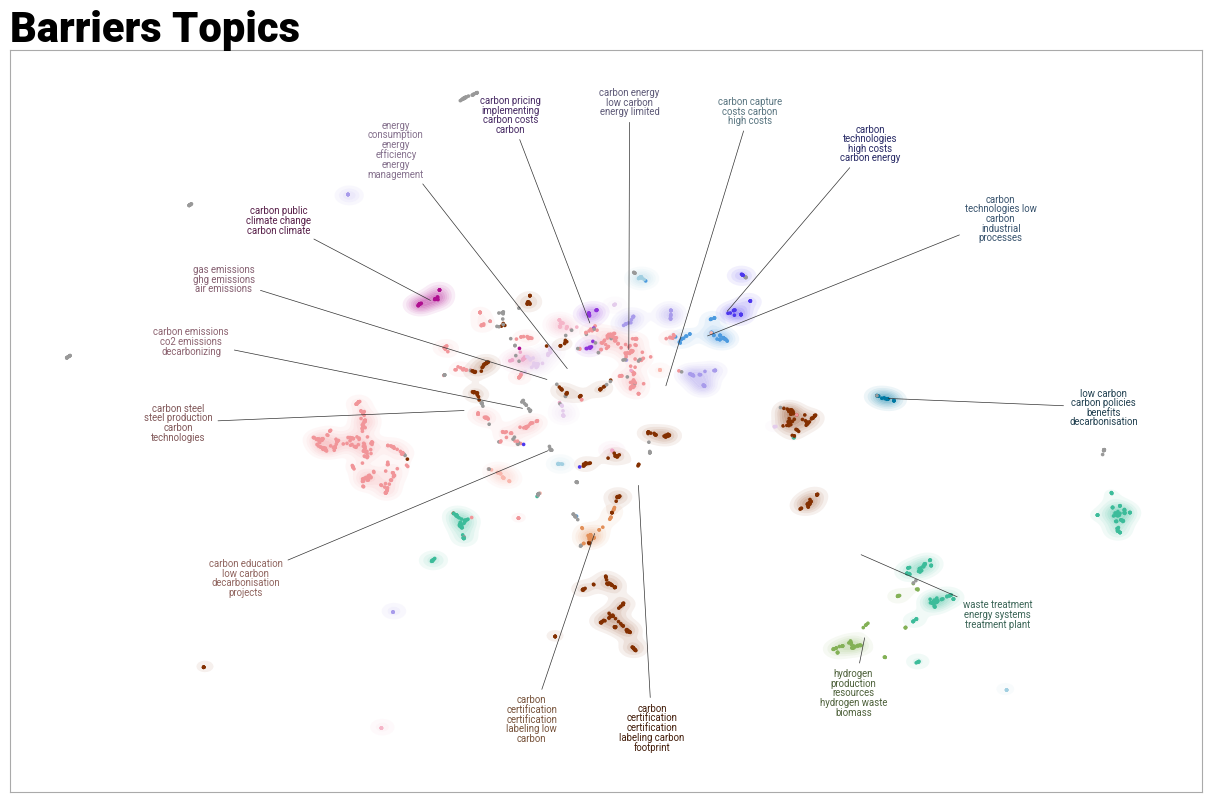

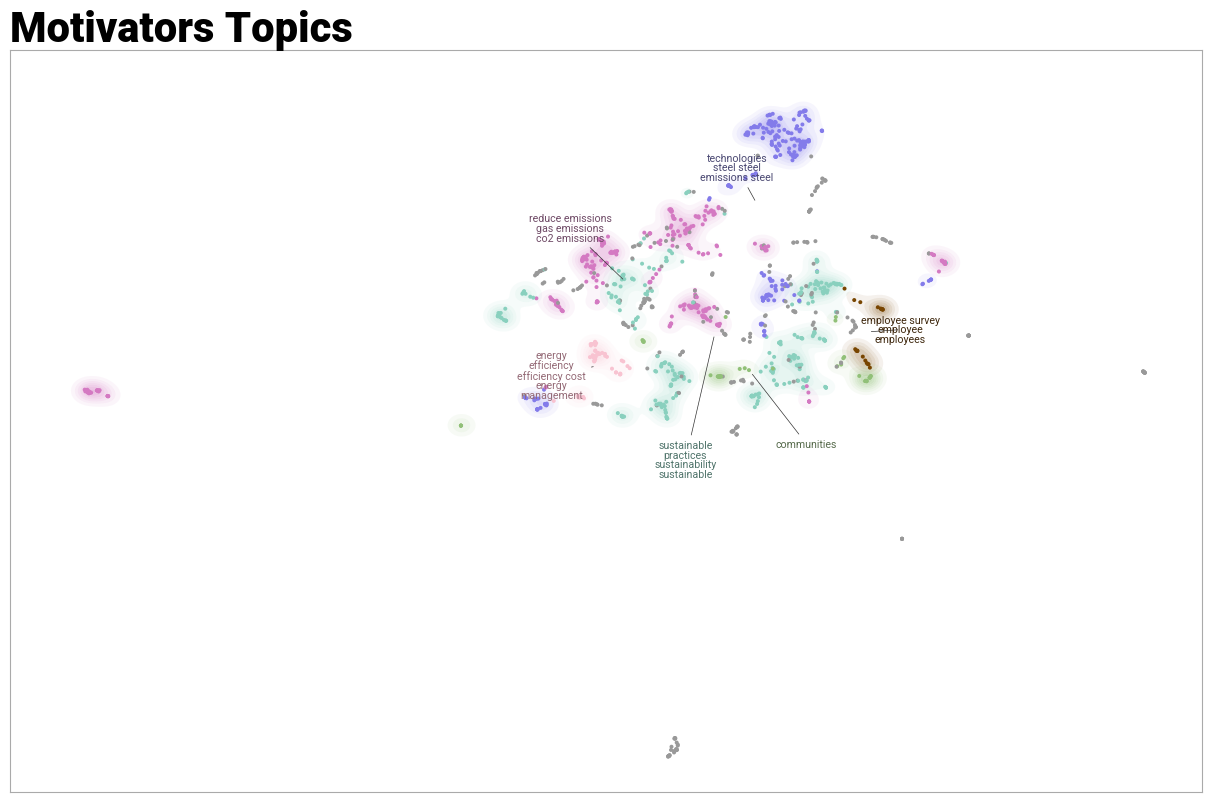

In [2]:
from nlp import merge_topics_pipeline, PipelineState

state = PipelineState.load_or_create("../out/topics/state.json")

# -- BARRIERS --
barriers_merges = [
    [6, 9, 12, 13],
    [18, 2, 17, 4, 0],
    [8, 11, 10, 3, 1],
    # [20, 5],
]
barriers_df = merge_topics_pipeline(category="barriers", topics_to_merge=barriers_merges, state=state)

# -- MOTIVATORS --
motivators_merges = [
    # [19, 8, 16, 2, 12, 20],
    [6, 4, 1, 9, 17, 19],       #sustainability, environment, climate change, recycling, supply chain
    [8, 15, 0],                 # innovative technology
    [3, 16, 11, 2, 5, 14, 13],  # carbon neutrality, emissions reduction, decarbonization plans
]
motivators_df = merge_topics_pipeline(category="motivators", topics_to_merge=motivators_merges, state=state)

### Deliverable — Top N Topics

Generates publication-ready output showing only the top `top_n` topics by doc count.  
Edit `top_n` below to control how many topics appear. Saves to `state.run_dir/deliverable/`.

📂 Loaded state from ../out/topics/state.json

📊 barriers: top 6 topics → [0, 1, 2, 3, 4, 5]
🖥️  GPU: NVIDIA T1200 Laptop GPU (3.9GB)
✅ Loaded model from ../out/topics/run_02/barriers_merged_model
✓ Loaded embeddings from original: ../out/topics/run_02/barriers_embeddings.npy

📉 Reducing embeddings to 2D for visualization...

📊 Generating visualizations for barriers...
   🔍 Filtering to 6 topics: [0, 1, 2, 3, 4, 5]
  ✓ barriers_barchart.html
  ✓ barriers_topics_2d.html
  ✓ barriers_hierarchy.html
  ✓ barriers_heatmap.html
  ✓ barriers_documents.html


12it [00:14,  1.23s/it]


  ✓ barriers_over_time.html


14it [00:15,  1.09s/it]


  ✓ barriers_per_company.html
  ✓ barriers_datamap.png

📊 motivators: top 6 topics → [0, 1, 2, 3, 4, 6]
🖥️  GPU: NVIDIA T1200 Laptop GPU (3.9GB)
✅ Loaded model from ../out/topics/run_02/motivators_merged_model
✓ Loaded embeddings from original: ../out/topics/run_02/motivators_embeddings.npy

📉 Reducing embeddings to 2D for visualization...

📊 Generating visualizations for motivators...
   🔍 Filtering to 6 topics: [0, 1, 2, 3, 4, 6]
  ✓ motivators_barchart.html
  ✓ motivators_topics_2d.html
  ✓ motivators_hierarchy.html
  ✓ motivators_heatmap.html
  ✓ motivators_documents.html


13it [00:10,  1.28it/s]


  ✓ motivators_over_time.html


13it [00:09,  1.40it/s]


  ✓ motivators_per_company.html
  ✓ motivators_datamap.png

✓ Deliverable saved to ../out/topics/run_02/deliverable


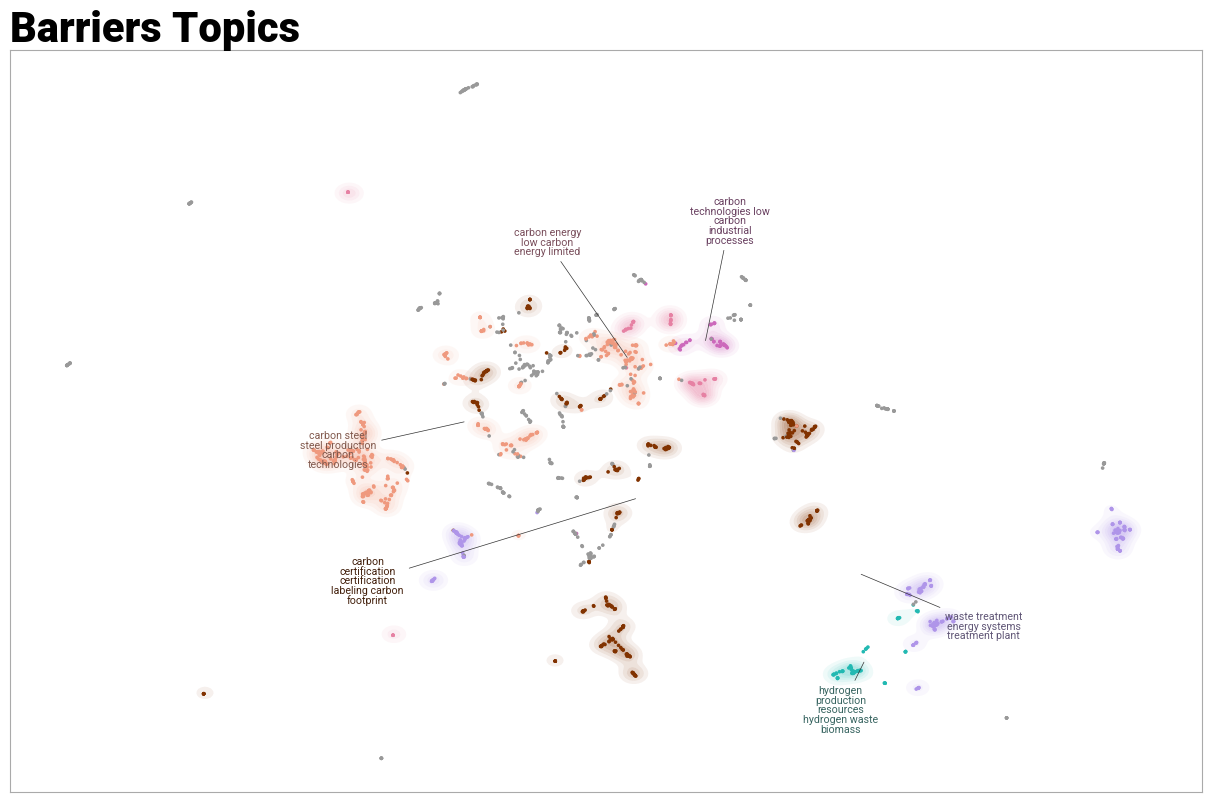

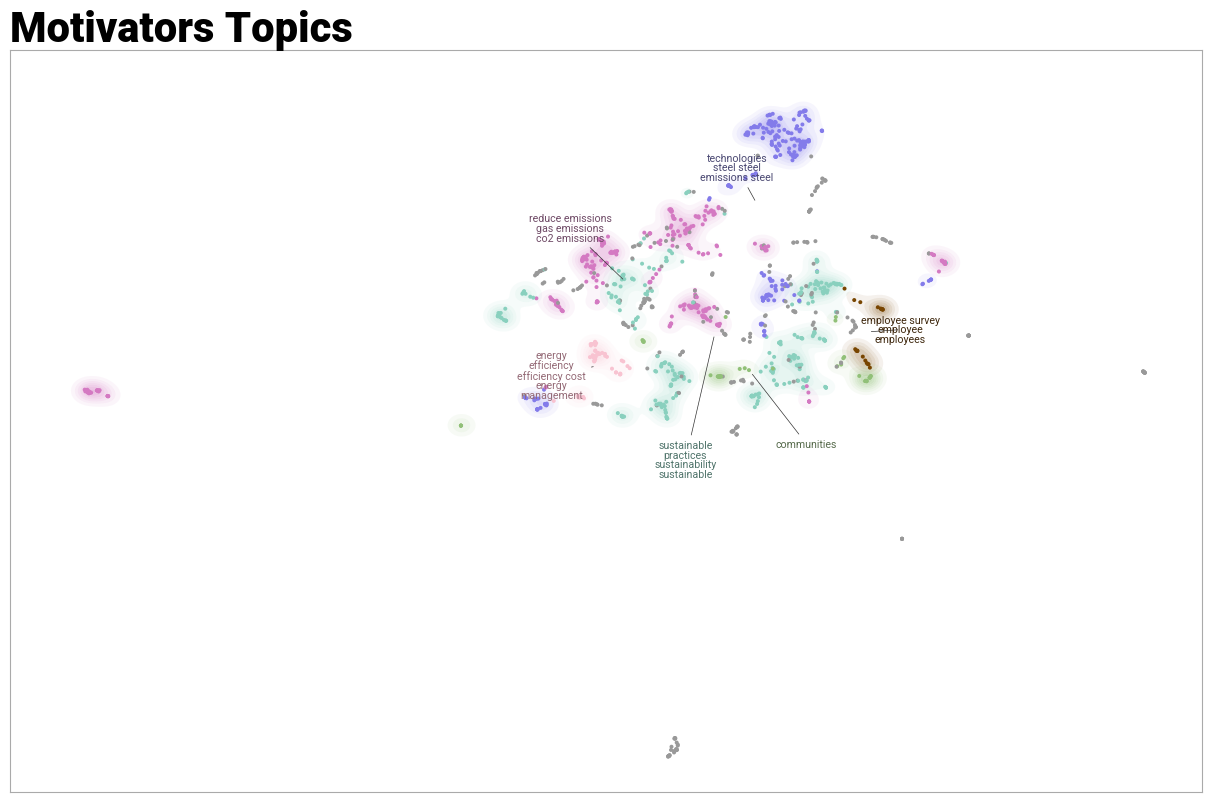

In [3]:
from nlp import generate_deliverable_viz, PipelineState

state = PipelineState.load_or_create("../out/topics/state.json")
top_n = 6  # topics to include (ranked by doc count)
generate_deliverable_viz(state=state, top_n=top_n)